In [9]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder

In [2]:
df=pd.read_csv('adult.csv')

In [3]:
features=['workclass','education','marital.status','occupation','relationship','race','native.country']

In [4]:
X=df[features]

In [7]:
X.isna().sum()

workclass         0
education         0
marital.status    0
occupation        0
relationship      0
race              0
native.country    0
dtype: int64

In [8]:
X.replace('?',np.nan)
X.fillna('Unknown')

,workclass,education,marital.status,occupation,relationship,race,native.country
0,?,HS-grad,Widowed,?,Not-in-family,White,United-States
1,Private,HS-grad,Widowed,Exec-managerial,Not-in-family,White,United-States
2,?,Some-college,Widowed,?,Unmarried,Black,United-States
3,Private,7th-8th,Divorced,Machine-op-inspct,Unmarried,White,United-States
4,Private,Some-college,Separated,Prof-specialty,Own-child,White,United-States
...,...,...,...,...,...,...,...
32556,Private,Some-college,Never-married,Protective-serv,Not-in-family,White,United-States
32557,Private,Assoc-acdm,Married-civ-spouse,Tech-support,Wife,White,United-States
32558,Private,HS-grad,Married-civ-spouse,Machine-op-inspct,Husband,White,United-States
32559,Private,HS-grad,Widowed,Adm-clerical,Unmarried,White,United-States


In [10]:
encoder=OrdinalEncoder()
X_encoded=encoder.fit_transform(X)

In [11]:
best_score=-1
best_k=0

from sklearn.cluster import AgglomerativeClustering

In [17]:
from sklearn.metrics import silhouette_score
for k in range(2,6):
    model=AgglomerativeClustering(n_clusters=k,linkage='average',metric='hamming')
    label=model.fit_predict(X_encoded)
    
    score=silhouette_score(X_encoded,label,metric='hamming')
    print(f"K={k},Score={score}")
    if score>best_score:
        best_score=score
        best_k=k

K=2,Score=0.33642393380156327
K=3,Score=0.2560971240402595
K=4,Score=0.21473737818957955
K=5,Score=0.15923022457296296


In [20]:
final_model=AgglomerativeClustering(
    n_clusters=best_k,
    linkage='average',
    metric='hamming'
)
label=final_model.fit_predict(X_encoded)

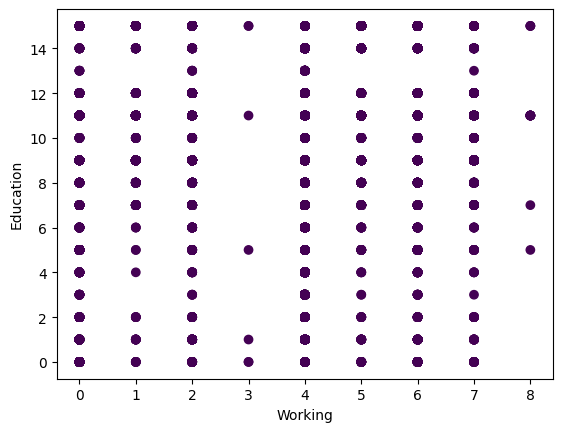

In [21]:
plt.scatter(X_encoded[:,0],X_encoded[:,1],c=label)
plt.xlabel('Working')
plt.ylabel('Education')

plt.show()